In [2]:
import simpy
import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. FUNCIONES Y CONSTANTES

In [ ]:
DIAS_SIMULACION = 5
TIEMPO_SIMULACION = DIAS_SIMULACION * 24 * 60  

def obtener_tiempo(minutos):
    minutos = int(minutos)
    return f"{(minutos//60)%24:02d}:{minutos%60:02d} día {minutos//(60*24) + 1}"

def prob_defecto(t_min):
    try:
        return 1 / (1 + math.exp((t_min - 40) / 13))
    except OverflowError:
        return 0.0

class Fabrica:
    def __init__(self, env, punto_critico):
        self.env = env
        self.punto_critico = punto_critico
        
        self.stock_cu = simpy.Container(env, capacity=500, init=500)
        self.stock_al = simpy.Container(env, capacity=500, init=500)
        self.rotores_listos = simpy.Store(env)
        self.estatores_listos = simpy.Store(env)
        self.operarios_rotor = simpy.Resource(env, capacity=2)
        self.operarios_estator = simpy.Resource(env, capacity=2)
        self.almacen_motores = simpy.Container(env, capacity=20, init=0)
        
        self.tiempos_espera = []
        self.total_rotores = 0
        self.defectos_rotores = 0
        self.total_estatores = 0
        self.defectos_estatores = 0

def control_stock(env, fabrica):
    while True:
        if fabrica.stock_cu.level < fabrica.punto_critico or fabrica.stock_al.level < fabrica.punto_critico:
            print(f"[{obtener_tiempo(env.now)}] ⚠️ SOLICITUD: Stock bajo. Cu: {fabrica.stock_cu.level}, Al: {fabrica.stock_al.level}. Pidiendo recarga.")
            
            yield env.timeout(8 * 60)
            
            yield fabrica.stock_cu.put(200)
            yield fabrica.stock_al.put(200)
            
            print(f"[{obtener_tiempo(env.now)}] 🚚 LLEGADA: Recarga lista. Nivel actual -> Cu: {fabrica.stock_cu.level} | Al: {fabrica.stock_al.level}")
            
        yield env.timeout(1)

def fabricar_pieza(env, fabrica, tipo, id_robot):
    while True:
        if fabrica.stock_cu.level < 8 or fabrica.stock_al.level < 8:
            print(f"[{obtener_tiempo(env.now)}] ⏸️ PARADA: Robot {tipo}-{id_robot} se detiene por falta de stock (Cu: {fabrica.stock_cu.level}, Al: {fabrica.stock_al.level}).")
            
        start_wait = env.now
        yield fabrica.stock_cu.get(8)
        yield fabrica.stock_al.get(8)
        tiempo_espera = env.now - start_wait
        
        if tiempo_espera > 0:
            fabrica.tiempos_espera.append(tiempo_espera)
            print(f"[{obtener_tiempo(env.now)}] ▶️ RETOMADA: Robot {tipo}-{id_robot} esperó {tiempo_espera:.1f} min y vuelve a la acción.")

        print(f"[{obtener_tiempo(env.now)}] 🟢 INICIO: Robot {tipo}-{id_robot} empieza a fabricar. Stock restante -> Cu: {fabrica.stock_cu.level} | Al: {fabrica.stock_al.level}")

        if tipo == 'Rotor':
            t_fab = max(30, random.gauss(60, 30))
        else:
            t_fab = max(30, random.gauss(120, 30))
            
        yield env.timeout(t_fab)
        
        print(f"[{obtener_tiempo(env.now)}] 🏁 FIN: Robot {tipo}-{id_robot} terminó de fabricar un {tipo} en {t_fab:.1f} minutos.")
        
        env.process(revisar_pieza(env, fabrica, tipo, id_robot, t_fab))

def revisar_pieza(env, fabrica, tipo, id_robot, t_fab):
    operarios = fabrica.operarios_rotor if tipo == 'Rotor' else fabrica.operarios_estator
    almacen_listos = fabrica.rotores_listos if tipo == 'Rotor' else fabrica.estatores_listos
    
    with operarios.request() as req:
        yield req
        
        if tipo == 'Rotor':
            yield env.timeout(max(30, random.gauss(120, 30)))
            fabrica.total_rotores += 1
        else:
            yield env.timeout(max(30, random.gauss(60, 30)))
            fabrica.total_estatores += 1
            
        if random.random() < prob_defecto(t_fab):
            if tipo == 'Rotor':
                fabrica.defectos_rotores += 1
            else:
                fabrica.defectos_estatores += 1
                
            print(f"[{obtener_tiempo(env.now)}] ❌ DESCARTE: {tipo} fabricado por Robot-{id_robot} fue defectuoso.")
        else:
            yield almacen_listos.put(1)
            print(f"[{obtener_tiempo(env.now)}] ✅ LISTO: {tipo} fabricado por Robot-{id_robot} superó la revisión y va a ensamblado.")

def linea_ensamblado(env, fabrica, id_linea):
    while True:
        yield fabrica.rotores_listos.get()
        yield fabrica.estatores_listos.get()
        
        print(f"[{obtener_tiempo(env.now)}] ⚙️ INICIO ENSAMBLADO: Línea-{id_linea} empieza a unir 1 Rotor y 1 Estator.")
        
        yield env.timeout(max(30, random.gauss(120, 60)))
        
        yield fabrica.almacen_motores.put(1)
        print(f"[{obtener_tiempo(env.now)}] 🏁🏁 FIN ENSAMBLADO: Motor creado en Línea-{id_linea} y guardado. (Total en almacén: {fabrica.almacen_motores.level})")

def control_almacen_salida(env, fabrica):
    while True:
        yield fabrica.almacen_motores.get(20)
        print(f"[{obtener_tiempo(env.now)}] 📦 ENVÍO EXTERNO: Se han retirado los 20 motores. Almacén vaciado.")

def ejecutar_simulacion(punto_critico=False):
    env = simpy.Environment()
    mi_fabrica = Fabrica(env, punto_critico)

    env.process(control_stock(env, mi_fabrica))
    env.process(control_almacen_salida(env, mi_fabrica))

    for i in range(1, 3):
        env.process(fabricar_pieza(env, mi_fabrica, 'Rotor', i))
        env.process(fabricar_pieza(env, mi_fabrica, 'Estator', i))

    for i in range(1, 4):
        env.process(linea_ensamblado(env, mi_fabrica, i))

    env.run(until=TIEMPO_SIMULACION)
    
    espera_media_run = np.mean(mi_fabrica.tiempos_espera) if mi_fabrica.tiempos_espera else 0.0
    return espera_media_run, mi_fabrica

## 2. SIMULACIÓN ÚNICA

In [ ]:
pc = 100
DIAS_SIMULACION = 5
TIEMPO_SIMULACION = DIAS_SIMULACION * 24 * 60  

print(f"--- INICIANDO SIMULACIÓN DE {DIAS_SIMULACION} DÍAS (PC: {pc}) ---")

espera_media, mi_fabrica = ejecutar_simulacion(pc)

print("--- FIN DE LA SIMULACIÓN ---")

print("\n==================================================")
print("           INFORME FINAL DE CALIDAD")
print("==================================================")

p_rotores = (mi_fabrica.defectos_rotores / mi_fabrica.total_rotores * 100) if mi_fabrica.total_rotores > 0 else 0
p_estatores = (mi_fabrica.defectos_estatores / mi_fabrica.total_estatores * 100) if mi_fabrica.total_estatores > 0 else 0

total_piezas = mi_fabrica.total_rotores + mi_fabrica.total_estatores
total_defectos = mi_fabrica.defectos_rotores + mi_fabrica.defectos_estatores
p_total = (total_defectos / total_piezas * 100) if total_piezas > 0 else 0

print(f"Rotores revisados: {mi_fabrica.total_rotores} (Descartados: {mi_fabrica.defectos_rotores}) -> {p_rotores:.2f}% Defectuosos")
print(f"Estatores revisados: {mi_fabrica.total_estatores} (Descartados: {mi_fabrica.defectos_estatores}) -> {p_estatores:.2f}% Defectuosos")
print("--------------------------------------------------")
print(f"TOTAL PIEZAS: {total_piezas} (Descartadas: {total_defectos}) -> {p_total:.2f}% DEFECTUOSIDAD GLOBAL")
print(f"Espera media del almacén: {espera_media:.2f} min")
print("==================================================\n")

datos_informe = {
    'Punto_Critico': [pc],
    'Dias_Simulacion': [DIAS_SIMULACION],
    'Rotores_Revisados': [mi_fabrica.total_rotores],
    'Rotores_Descartados': [mi_fabrica.defectos_rotores],
    'Porcentaje_Defectos_Rotores': [round(p_rotores, 2)],
    'Estatores_Revisados': [mi_fabrica.total_estatores],
    'Estatores_Descartados': [mi_fabrica.defectos_estatores],
    'Porcentaje_Defectos_Estatores': [round(p_estatores, 2)],
    'Total_Piezas': [total_piezas],
    'Total_Defectos': [total_defectos],
    'Porcentaje_Defectos_Global': [round(p_total, 2)],
    'Espera_Media_Min': [round(espera_media, 2)]}

df_calidad = pd.DataFrame(datos_informe)
df_calidad.to_csv('informe_calidad_simulacion.csv', index=False)
print("Informe guardado en 'informe_calidad_simulacion.csv'")

--- INICIANDO SIMULACIÓN DE 5 DÍAS (PC: 100) ---
[00:00 día 1] 🟢 INICIO: Robot Rotor-1 empieza a fabricar. Stock restante -> Cu: 468 | Al: 468
[00:00 día 1] 🟢 INICIO: Robot Estator-1 empieza a fabricar. Stock restante -> Cu: 468 | Al: 468
[00:00 día 1] 🟢 INICIO: Robot Rotor-2 empieza a fabricar. Stock restante -> Cu: 468 | Al: 468
[00:00 día 1] 🟢 INICIO: Robot Estator-2 empieza a fabricar. Stock restante -> Cu: 468 | Al: 468
[01:05 día 1] 🏁 FIN: Robot Rotor-1 terminó de fabricar un Rotor en 65.1 minutos.
[01:05 día 1] 🟢 INICIO: Robot Rotor-1 empieza a fabricar. Stock restante -> Cu: 460 | Al: 460
[01:13 día 1] 🏁 FIN: Robot Rotor-2 terminó de fabricar un Rotor en 73.0 minutos.
[01:13 día 1] 🟢 INICIO: Robot Rotor-2 empieza a fabricar. Stock restante -> Cu: 452 | Al: 452
[01:35 día 1] 🏁 FIN: Robot Rotor-1 terminó de fabricar un Rotor en 30.0 minutos.
[01:35 día 1] 🟢 INICIO: Robot Rotor-1 empieza a fabricar. Stock restante -> Cu: 444 | Al: 444
[01:54 día 1] 🏁 FIN: Robot Rotor-2 terminó de 

In [ ]:
COLOR_BASE = "#00929a"
COLOR_OSCURO = "#006d73"
COLOR_CLARO = "#4bb8be"
COLOR_MUY_CLARO = "#d9f1f2"
COLOR_GRID = "#b7dfe2"
COLOR_TEXTO = "#1f2d2f"

plt.rcParams['text.color'] = COLOR_TEXTO
plt.rcParams['axes.labelcolor'] = COLOR_TEXTO
plt.rcParams['xtick.color'] = COLOR_TEXTO
plt.rcParams['ytick.color'] = COLOR_TEXTO
plt.rcParams['axes.axisbelow'] = True

df_calidad = pd.read_csv('informe_calidad_simulacion.csv')
datos = df_calidad.iloc[-1]


rot_rev = datos['Rotores_Revisados']
rot_def = datos['Rotores_Descartados']
rot_ok = rot_rev - rot_def

est_rev = datos['Estatores_Revisados']
est_def = datos['Estatores_Descartados']
est_ok = est_rev - est_def

tot_piezas = datos['Total_Piezas']
tot_def = datos['Total_Defectos']
tot_ok = tot_piezas - tot_def

pc_usado = datos['Punto_Critico']

propiedades_bordes = {'edgecolor': COLOR_OSCURO, 'linewidth': 1.2}

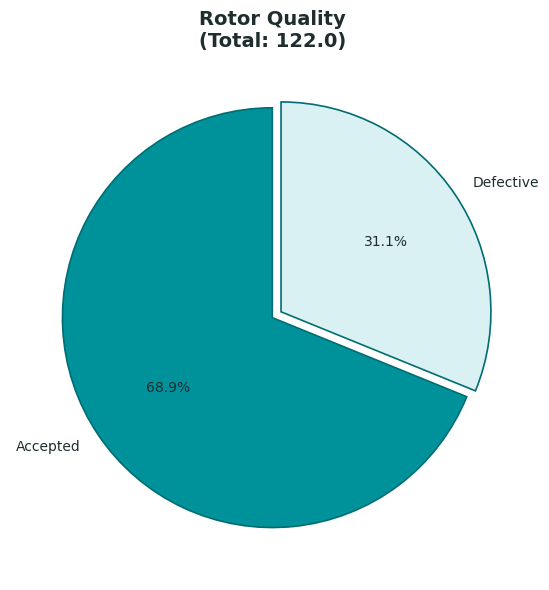

In [ ]:
plt.figure(figsize=(6, 6))

plt.pie([rot_ok, rot_def], labels=['Accepted', 'Defective'], autopct='%1.1f%%', 
        colors=[COLOR_BASE, COLOR_MUY_CLARO], startangle=90, 
        explode=(0, 0.05), wedgeprops=propiedades_bordes)
plt.title(f'Rotor Quality\n(Total: {rot_rev})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

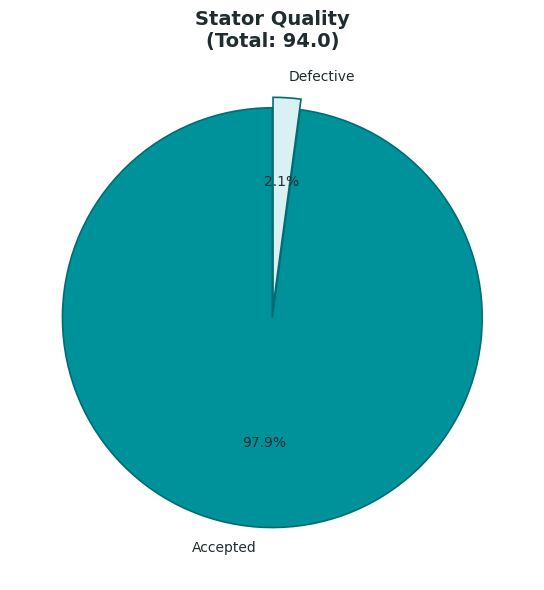

In [ ]:
plt.figure(figsize=(6, 6))

plt.pie([est_ok, est_def], labels=['Accepted', 'Defective'], autopct='%1.1f%%', 
        colors=[COLOR_BASE, COLOR_MUY_CLARO], startangle=90, 
        explode=(0, 0.05), wedgeprops=propiedades_bordes)

plt.title(f'Stator Quality\n(Total: {est_rev})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

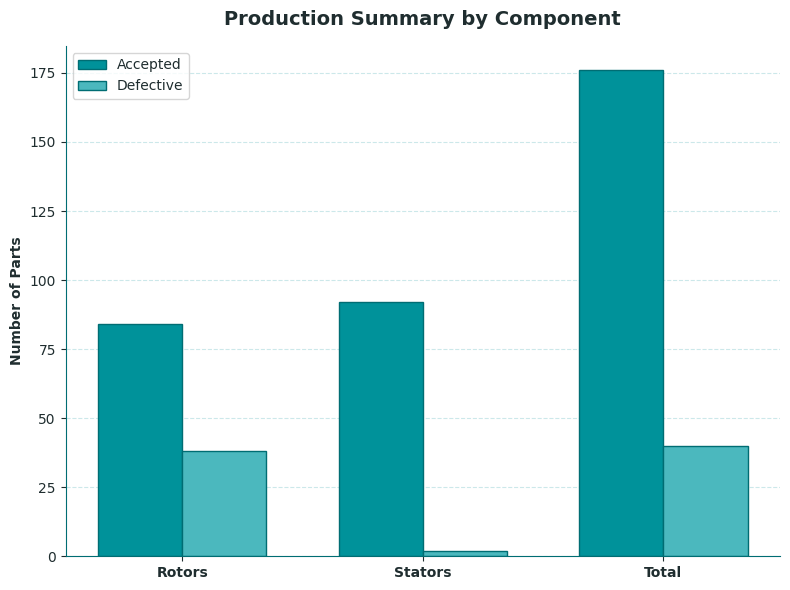

In [ ]:
plt.figure(figsize=(8, 6))

etiquetas = ['Rotors', 'Stators', 'Total']
valores_ok = [rot_ok, est_ok, tot_ok]
valores_def = [rot_def, est_def, tot_def]

x = np.arange(len(etiquetas))
ancho = 0.35

plt.bar(x - ancho/2, valores_ok, ancho, label='Accepted', color=COLOR_BASE, edgecolor=COLOR_OSCURO)
plt.bar(x + ancho/2, valores_def, ancho, label='Defective', color=COLOR_CLARO, edgecolor=COLOR_OSCURO)

plt.ylabel('Number of Parts', fontweight='bold')
plt.title('Production Summary by Component', fontsize=14, fontweight='bold', pad=15)
plt.xticks(x, etiquetas, fontweight='bold')
plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.7, color=COLOR_GRID)
ax = plt.gca() 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(COLOR_OSCURO)
ax.spines['bottom'].set_color(COLOR_OSCURO)

plt.tight_layout()
plt.show()

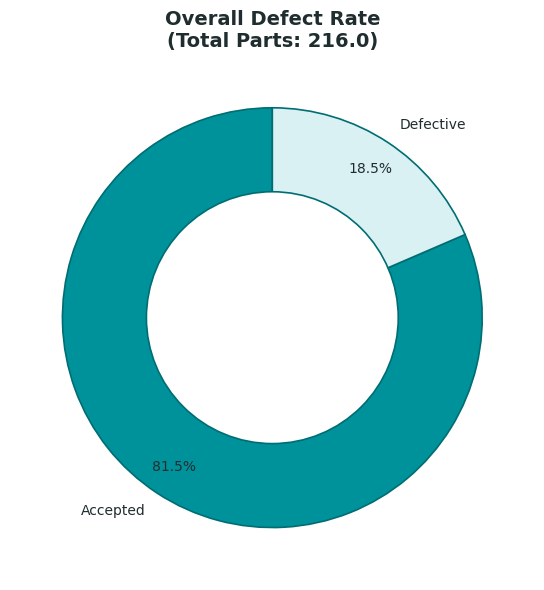

In [ ]:
plt.figure(figsize=(6, 6))

plt.pie([tot_ok, tot_def], labels=['Accepted', 'Defective'], autopct='%1.1f%%', 
        colors=[COLOR_BASE, COLOR_MUY_CLARO], startangle=90, pctdistance=0.85,
        wedgeprops=propiedades_bordes)

centro_blanco = plt.Circle((0,0), 0.60, fc='white', ec=COLOR_OSCURO, lw=1.2)
plt.gca().add_artist(centro_blanco)

plt.title(f'Overall Defect Rate\n(Total Parts: {tot_piezas})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

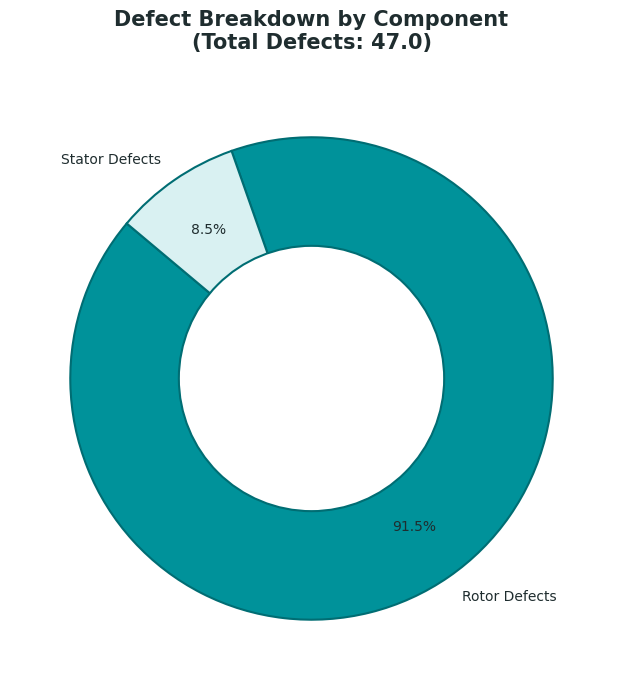

In [ ]:
plt.figure(figsize=(7, 7), facecolor='white')

valores = [rot_def, est_def]
etiquetas = ['Rotor Defects', 'Stator Defects']
colores = [COLOR_BASE, COLOR_MUY_CLARO]

plt.pie(valores, labels=etiquetas, autopct='%1.1f%%', startangle=140, 
        colors=colores, pctdistance=0.75,
        wedgeprops={'edgecolor': COLOR_OSCURO, 'linewidth': 1.5})
centro_blanco = plt.Circle((0,0), 0.55, fc='white', ec=COLOR_OSCURO, lw=1.5)
plt.gca().add_artist(centro_blanco)
plt.title(f'Defect Breakdown by Component\n(Total Defects: {tot_def})', 
          fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 3. BÚSQUEDA DE **PC** ÓPTIMO

In [ ]:
def formatear_tiempo(minutos_totales):
    seg_totales = int(round(minutos_totales * 60))
    horas = seg_totales // 3600
    minutos = (seg_totales % 3600) // 60
    segundos = seg_totales % 60
    return f"{horas}h {minutos}min {segundos}s"

puntos_prueba = np.linspace(100, 400, 301)
simulaciones = 100


datos_completos = []

print(f"Buscando el Punto Crítico Óptimo sobre la Fábrica Completa...")
print(f"Ejecutando {simulaciones} simulaciones por cada escenario.")
print(f"\n{'PC':<5} | {'Espera Media':<18} | {'Runs c/Parada':<15} | {'Paradas/Run':<12} | {'Peor Parada':<18}")
print("-" * 85)

for pc in puntos_prueba:
    pc = int(pc)
    esperas = []
    paradas_por_run = []
    max_por_run = []

    for _ in range(simulaciones):
        espera, mi_fabrica = ejecutar_simulacion(pc=False)
        esperas.append(espera)
        
        num_paradas = len(mi_fabrica.tiempos_espera)
        paradas_por_run.append(num_paradas)
        max_por_run.append(max(mi_fabrica.tiempos_espera) if num_paradas > 0 else 0.0)

    
    espera_media_total = np.mean(esperas)
    runs_con_parada = sum(1 for x in paradas_por_run if x > 0)
    paradas_media = np.mean(paradas_por_run)
    peor_max = max(max_por_run)

    
    datos_completos.append({
        'PC': pc,
        'Espera Media': espera_media_total,
        'Runs c/Parada': runs_con_parada,
        'Paradas/Run': paradas_media,
        'Peor Parada': peor_max
    })

    espera_fmt = formatear_tiempo(espera_media_total)
    peor_max_fmt = formatear_tiempo(peor_max)

    print(
        f"{pc:3d}   | {espera_fmt:<18} | "
        f"{runs_con_parada:4d}/{simulaciones:<10} | {paradas_media:11.2f} | "
        f"{peor_max_fmt:<18}"
    )

df_resultados = pd.DataFrame(datos_completos)
df_resultados.to_csv('resultados_optimizacion.csv', index=False)
print("\nDatos guardados con éxito en 'resultados_optimizacion.csv'.")

Buscando el Punto Crítico Óptimo sobre la Fábrica Completa...
Ejecutando 100 simulaciones por cada escenario.

PC    | Espera Media       | Runs c/Parada   | Paradas/Run  | Peor Parada       
-------------------------------------------------------------------------------------
100   | 3h 16min 11s       |  100/100        |       34.24 | 5h 9min 35s       
101   | 2h 57min 11s       |  100/100        |       35.93 | 5h 6min 58s       
102   | 2h 52min 41s       |  100/100        |       35.88 | 4h 59min 18s      
103   | 2h 58min 46s       |  100/100        |       35.74 | 4h 59min 58s      
104   | 2h 55min 42s       |  100/100        |       35.97 | 5h 18min 24s      
105   | 2h 55min 57s       |  100/100        |       35.83 | 5h 9min 47s       
106   | 2h 55min 31s       |  100/100        |       35.95 | 5h 1min 37s       
107   | 2h 55min 45s       |  100/100        |       35.83 | 4h 47min 2s       
108   | 2h 54min 49s       |  100/100        |       35.94 | 5h 1min 43s       
10

In [ ]:
pcs_ordenados_inv = sorted(df_resultados['PC'], reverse=True)

pc_optimo = pcs_ordenados_inv[0] 

for pc in pcs_ordenados_inv:
    if df_resultados[df_resultados['PC'] == pc]['Espera Media'].item() == 0:
        pc_optimo = pc
    else:
        
        break

pcs_ordenados = sorted(df_resultados['PC'])
primer_pc_optimo = pcs_ordenados[0]

for pc in pcs_ordenados:
    if df_resultados[df_resultados['PC'] == pc]['Espera Media'].item() == 0:
        primer_pc_optimo = pc
        break
    else:
        continue

print(f"\n>>>> EL PRIMER PUNTO CRÍTICO ÓPTIMO ES:  {primer_pc_optimo} <<<<")
print(f"\n>>>> EL PUNTO CRÍTICO ÓPTIMO ESTABLE ES: {pc_optimo} <<<<")


>>>> EL PRIMER PUNTO CRÍTICO ÓPTIMO ES:  252 <<<<

>>>> EL PUNTO CRÍTICO ÓPTIMO ESTABLE ES: 272 <<<<


## 4. VISUALIZACIÓN DE PC

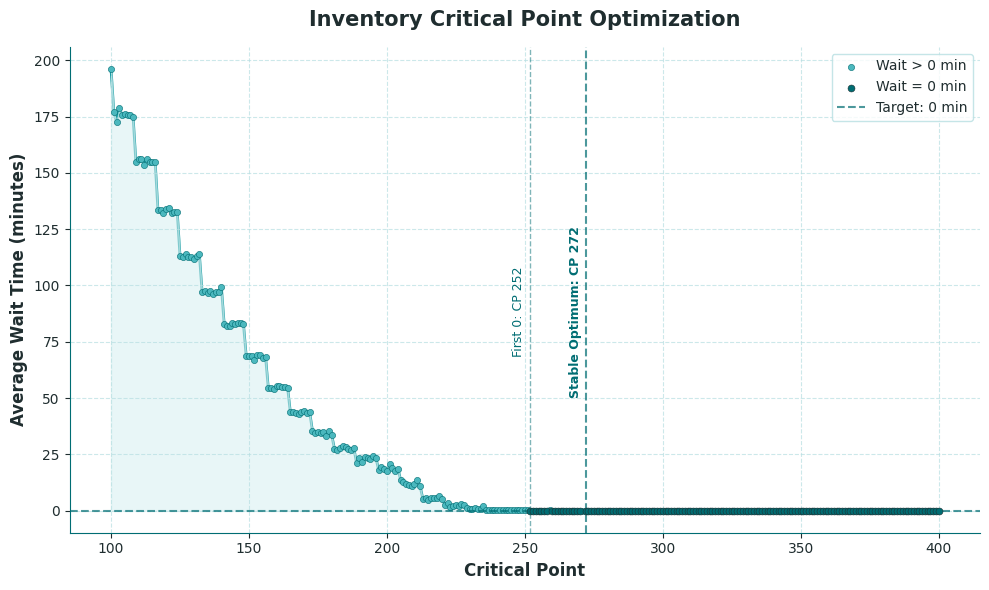

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

COLOR_BASE = "#00929a"
COLOR_OSCURO = "#006d73"
COLOR_CLARO = "#4bb8be"
COLOR_MUY_CLARO = "#d9f1f2"
COLOR_GRID = "#b7dfe2"
COLOR_TEXTO = "#1f2d2f"

plt.rcParams['text.color'] = COLOR_TEXTO
plt.rcParams['axes.labelcolor'] = COLOR_TEXTO
plt.rcParams['xtick.color'] = COLOR_TEXTO
plt.rcParams['ytick.color'] = COLOR_TEXTO

df = pd.read_csv('resultados_optimizacion.csv')

x = df['PC'].tolist()
y = df['Espera Media'].tolist()
resultados_csv = dict(zip(x, y))

plt.figure(figsize=(10, 6), facecolor='white')

plt.plot(x, y, linestyle='-', linewidth=2, color=COLOR_BASE, zorder=1)

x_mayor = [x[i] for i in range(len(y)) if y[i] > 0]
y_mayor = [y[i] for i in range(len(y)) if y[i] > 0]

x_cero = [x[i] for i in range(len(y)) if y[i] == 0]
y_cero = [y[i] for i in range(len(y)) if y[i] == 0]

plt.scatter(x_mayor, y_mayor, color=COLOR_CLARO, edgecolor=COLOR_OSCURO,
            linewidths=0.4, s=20, zorder=2, label='Wait > 0 min')

plt.scatter(x_cero, y_cero, color=COLOR_OSCURO, edgecolor=COLOR_TEXTO,
            linewidths=0.4, s=25, zorder=3, label='Wait = 0 min')

plt.fill_between(x, y, 0, color=COLOR_MUY_CLARO, alpha=0.6)

plt.axhline(0, color=COLOR_OSCURO, linestyle='--', linewidth=1.5, alpha=0.7, label='Target: 0 min')

primer_pc_optimo = min([pc for pc, esp in resultados_csv.items() if esp == 0])

pcs_ordenados = sorted(resultados_csv.keys(), reverse=True)
pc_optimo = pcs_ordenados[0]
for pc in pcs_ordenados:
    if resultados_csv[pc] == 0:
        pc_optimo = pc
    else:
        break

plt.axvline(pc_optimo, color=COLOR_OSCURO, linestyle='--', linewidth=1.5, alpha=0.7)
plt.axvline(primer_pc_optimo, color=COLOR_OSCURO, linestyle='--', linewidth=1, alpha=0.5)

altura_texto = max(y) * 0.45 

plt.annotate(f'First 0: CP {primer_pc_optimo}', 
             xy=(primer_pc_optimo, altura_texto), 
             xytext=(-4, 0),
             textcoords='offset points', 
             ha='right', 
             va='center',
             rotation=90, 
             fontsize=9,
             color=COLOR_OSCURO)

plt.annotate(f'Stable Optimum: CP {pc_optimo}', 
             xy=(pc_optimo, altura_texto), 
             xytext=(-12, 0),
             textcoords='offset points', 
             ha='left',
             va='center',
             rotation=90, 
             fontsize=9, 
             fontweight='bold', 
             color=COLOR_OSCURO)

plt.title('Inventory Critical Point Optimization', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Critical Point', fontsize=12, fontweight='bold')
plt.ylabel('Average Wait Time (minutes)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7, color=COLOR_GRID)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(COLOR_OSCURO)
ax.spines['bottom'].set_color(COLOR_OSCURO)
plt.legend(frameon=True, facecolor='white', edgecolor=COLOR_GRID)
plt.tight_layout()
plt.show()